Modeller Karşılaştırılıyor...



,Model,Doğruluk (%),F1-Score (%),Gecikme (ms),FPS,Parametre (M),Boyut (MB)
0,ResNet-18,99.08,99.08,2.98,335.8,11.18,42.71
1,MobileNetV3-Large,99.23,99.23,7.23,138.3,3.96,15.30
2,DenseNet-121,99.14,99.14,23.94,41.8,6.96,27.12


C:\Users\sibel\AppData\Local\Temp\ipykernel_39280\210914758.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Model", y="Doğruluk (%)", palette="viridis")
C:\Users\sibel\AppData\Local\Temp\ipykernel_39280\210914758.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Model", y="FPS", palette="mako")


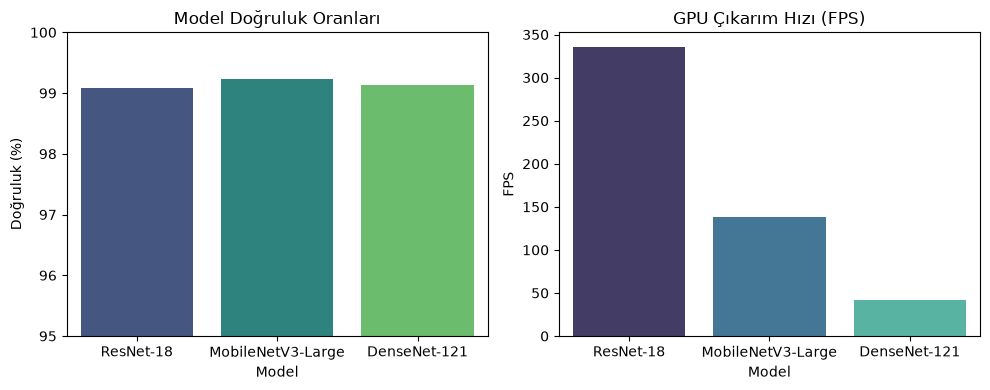

In [1]:
import sys
sys.path.append('..')

import os
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

from src.dataset import get_dataloaders
from src.models import build_resnet18, build_mobilenetv3, build_densenet121

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
_, val_loader, _, class_names = get_dataloaders(data_dir="../dataset/raw", batch_size=32)

model_configs = [
    {
        "name": "ResNet-18",
        "model": build_resnet18(num_classes=2, pretrained=False),
        "path": "../models/best_resnet18.pth"
    },
    {
        "name": "MobileNetV3-Large",
        "model": build_mobilenetv3(num_classes=2, pretrained=False),
        "path": "../models/best_mobilenetv3.pth"
    },
    {
        "name": "DenseNet-121",
        "model": build_densenet121(num_classes=2, pretrained=False),
        "path": "../models/best_densenet121.pth"
    }
]

results = []
dummy_input = torch.randn(1, 3, 224, 224).to(device)

print("Modeller Karşılaştırılıyor...\n")

for cfg in model_configs:
    model = cfg["model"]
    model.load_state_dict(torch.load(cfg["path"], map_location=device, weights_only=True))
    model.to(device)
    model.eval()

    # 1. Parametre Sayısı ve Dosya Boyutu
    params_m = sum(p.numel() for p in model.parameters()) / 1e6
    file_size_mb = os.path.getsize(cfg["path"]) / (1024 * 1024)

    # 2. Gecikme (Latency) ve FPS Ölçümü
    with torch.no_grad():
        for _ in range(20):
            _ = model(dummy_input)
        if device.type == 'cuda':
            torch.cuda.synchronize()

        start = time.time()
        for _ in range(100):
            _ = model(dummy_input)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        latency_ms = ((time.time() - start) / 100) * 1000
        fps = 1000.0 / latency_ms

    # 3. Doğruluk ve F1 Skoru
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds) * 100
    f1 = f1_score(all_labels, all_preds, average='weighted') * 100

    results.append({
        "Model": cfg["name"],
        "Doğruluk (%)": round(acc, 2),
        "F1-Score (%)": round(f1, 2),
        "Gecikme (ms)": round(latency_ms, 2),
        "FPS": round(fps, 1),
        "Parametre (M)": round(params_m, 2),
        "Boyut (MB)": round(file_size_mb, 2)
    })

df = pd.DataFrame(results)
display(df)

# Grafiksel Karşılaştırma
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.barplot(data=df, x="Model", y="Doğruluk (%)", palette="viridis")
plt.title("Model Doğruluk Oranları")
plt.ylim(95, 100)

plt.subplot(1, 2, 2)
sns.barplot(data=df, x="Model", y="FPS", palette="mako")
plt.title("GPU Çıkarım Hızı (FPS)")

plt.tight_layout()
plt.show()